# Data visualization

Explore the application data prepared in `01_data_preparation.ipynb`.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    if (PROJECT_ROOT.parent / "src").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent
    else:
        raise FileNotFoundError(
            "Run this notebook from the P4 project root or the notebooks folder."
        )

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

index_cols = ["TARGET", "SK_ID_CURR", "SK_ID_BUREAU", "SK_ID_PREV", "index", "DAYS_ID_PUBLISH"]

from src.functions import *

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 10)

# csv_to_pkl()


# Visualization

In [2]:
with open('./data/application_visualization.pkl', 'rb') as pickle_file:
    df_visualization = pickle.load(pickle_file)

with open('./data/application_prepared.pkl', 'rb') as pickle_file:
    df_prepared = pickle.load(pickle_file)

df = df_visualization.copy()

In [3]:
df.info()

<class 'pandas.DataFrame'>
MultiIndex: 356255 entries, ('test', np.int64(0)) to ('train', np.int64(307510))
Columns: 123 entries, SK_ID_CURR to AGE_GROUP
dtypes: float64(67), int64(40), str(16)
memory usage: 338.4+ MB


In [4]:
print('There are {} rows '.format(df.shape[0]) + 'and {} columns'.format(df.shape[1]))

There are 356255 rows and 123 columns


In [5]:
# Data dtypes
df.info()
#df.info(verbose=True, max_cols=df.shape[1])

<class 'pandas.DataFrame'>
MultiIndex: 356255 entries, ('test', np.int64(0)) to ('train', np.int64(307510))
Columns: 123 entries, SK_ID_CURR to AGE_GROUP
dtypes: float64(67), int64(40), str(16)
memory usage: 338.4+ MB


In [6]:
# Check for missing values
df.isnull().mean().sort_values()

SK_ID_CURR                  0.000000
NAME_CONTRACT_TYPE          0.000000
FLAG_OWN_CAR                0.000000
FLAG_OWN_REALTY             0.000000
AMT_INCOME_TOTAL            0.000000
                              ...   
NONLIVINGAPARTMENTS_AVG     0.692933
NONLIVINGAPARTMENTS_MEDI    0.692933
COMMONAREA_MODE             0.697141
COMMONAREA_AVG              0.697141
COMMONAREA_MEDI             0.697141
Length: 123, dtype: float64

In [7]:
print((df.isnull().mean() > 0.5).sum(), "columns have more than 50% of missing values")

37 columns have more than 50% of missing values


In [8]:
df.describe()

,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,...,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,TARGET,AGE_GROUP
count,356255.000000,356255.000000,3.562550e+05,3.562550e+05,356219.000000,3.559770e+05,356255.000000,356255.000000,291607.000000,356255.000000,356255.000000,121014.000000,356255.000000,356255.000000,356255.000000,356255.000000,356255.000000,356255.000000,356253.000000,356255.000000,356255.000000,356255.000000,356255.000000,356255.000000,356255.000000,356255.000000,356255.000000,356255.000000,162345.000000,3.555870e+05,286622.000000,176307.000000,148671.000000,183392.000000,119949.000000,107895.000000,167175.000000,177848.000000,179914.000000,115147.000000,145411.000000,113276.000000,178353.000000,109394.000000,160489.000000,176307.000000,148671.000000,183392.000000,119949.000000,107895.000000,...,109394.000000,160489.000000,176307.000000,148671.000000,183392.000000,119949.000000,107895.000000,167175.000000,177848.000000,179914.000000,115147.000000,145411.000000,113276.000000,178353.000000,109394.000000,160489.000000,185200.000000,355205.000000,355205.000000,355205.000000,355205.000000,356254.000000,356255.000000,356255.000000,356255.000000,356255.000000,356255.000000,356255.000000,356255.000000,356255.000000,356255.000000,356255.000000,356255.000000,356255.000000,356255.000000,356255.000000,356255.000000,356255.00000,356255.000000,356255.000000,356255.000000,356255.000000,308687.000000,308687.000000,308687.000000,308687.000000,308687.000000,308687.000000,307511.000000,356255.000000
mean,278128.000000,0.414316,1.701161e+05,5.877674e+05,27425.560657,5.280200e+05,0.020917,-16041.248841,-2396.698937,-4983.593527,-3002.071163,12.023741,0.999994,0.818498,0.200098,0.998170,0.278612,0.071213,2.151858,2.050506,2.028932,12.055749,0.015649,0.051371,0.040847,0.078076,0.229661,0.178824,0.501965,5.148900e-01,0.509350,0.118138,0.088673,0.977889,0.752283,0.045045,0.079819,0.150015,0.227331,0.232817,0.066454,0.101495,0.108089,0.008868,0.028503,0.114914,0.087750,0.977239,0.759452,0.042930,...,0.008116,0.027183,0.118549,0.088178,0.977903,0.755548,0.044994,0.078930,0.149494,0.226922,0.232504,0.067296,0.102674,0.109279,0.008697,0.028386,0.103193,1.425729,0.143452,1.409468,0.100198,-978.580852,0.000036,0.720504,0.000084,0.015065,0.087976,0.000171,0.082346,0.003977

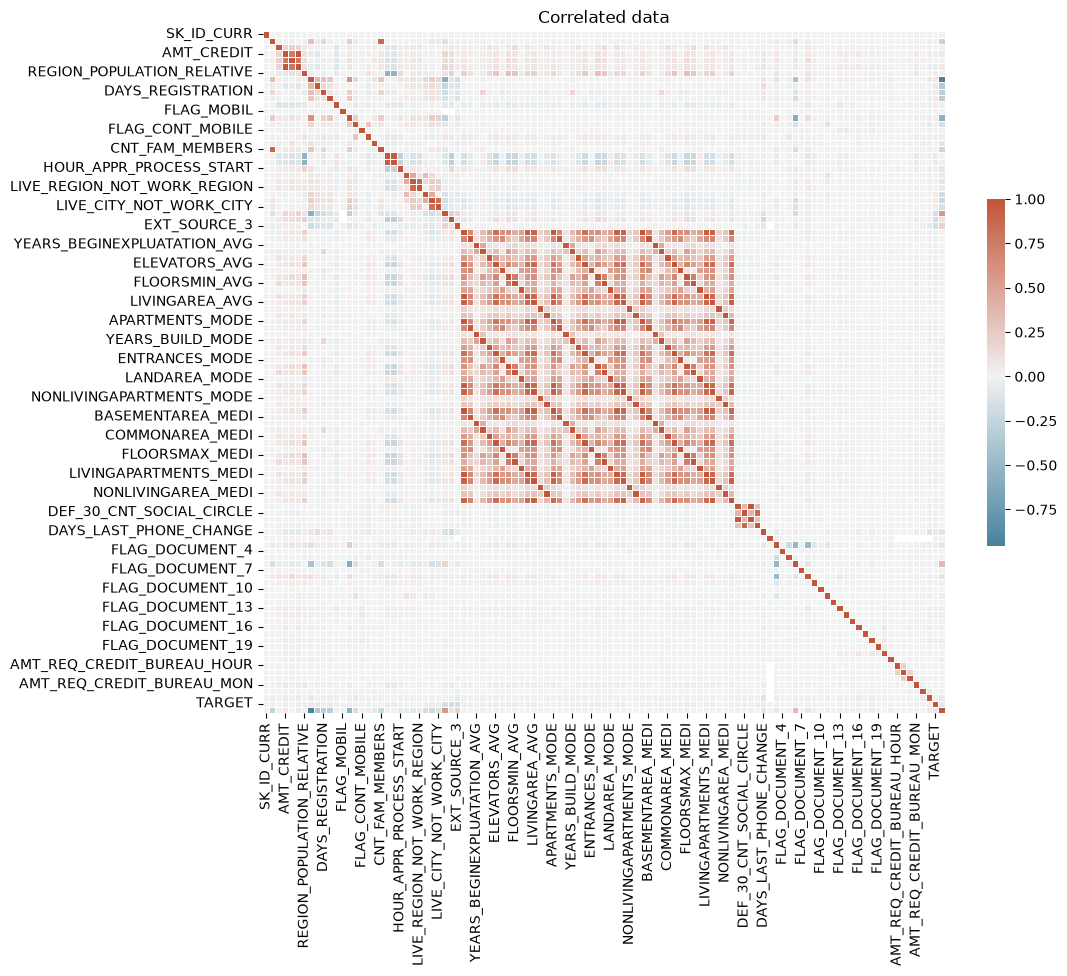

In [9]:
display_correlated_data(df)

We do not see any good correlation to our TARGET. We notice that some features are highly correlated (the big red box)

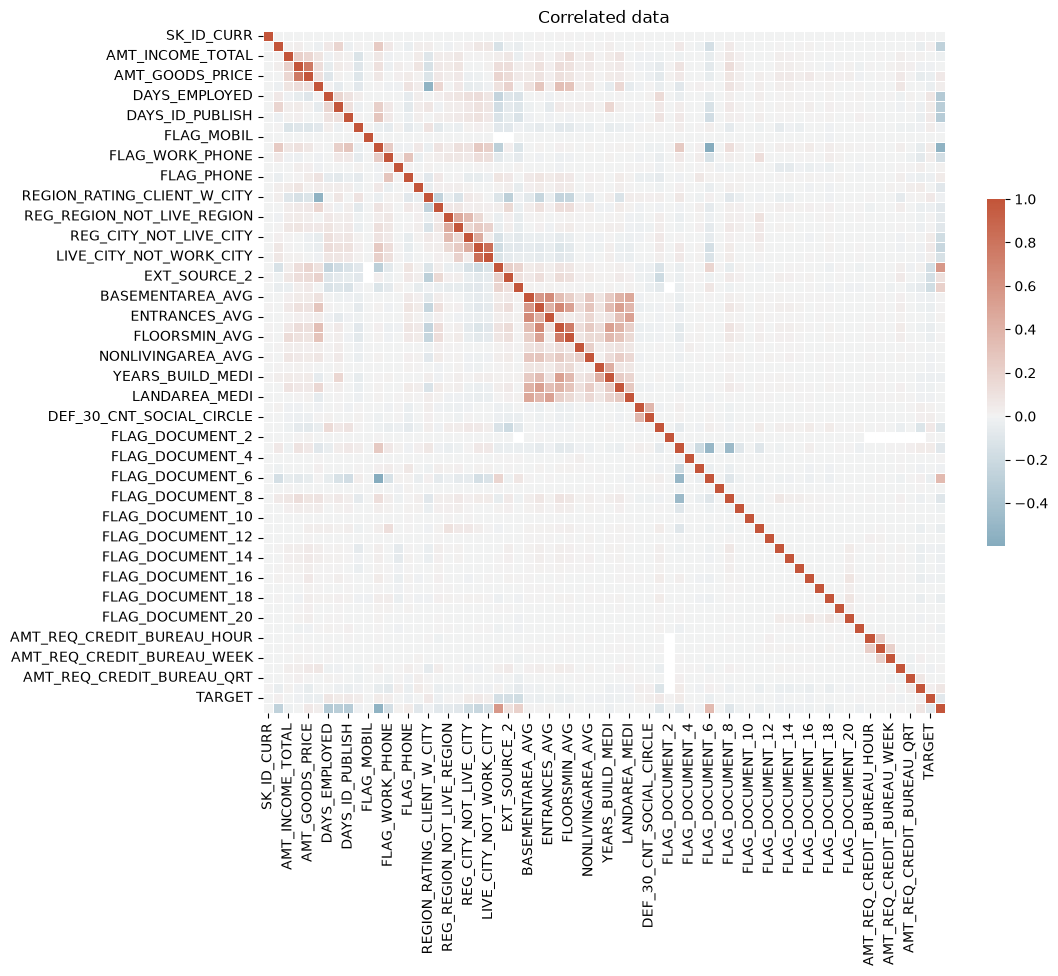

In [10]:
display_correlated_data(df.drop(columns=get_correlated_columns(df, 'TARGET', 0.80)))

<Axes: >

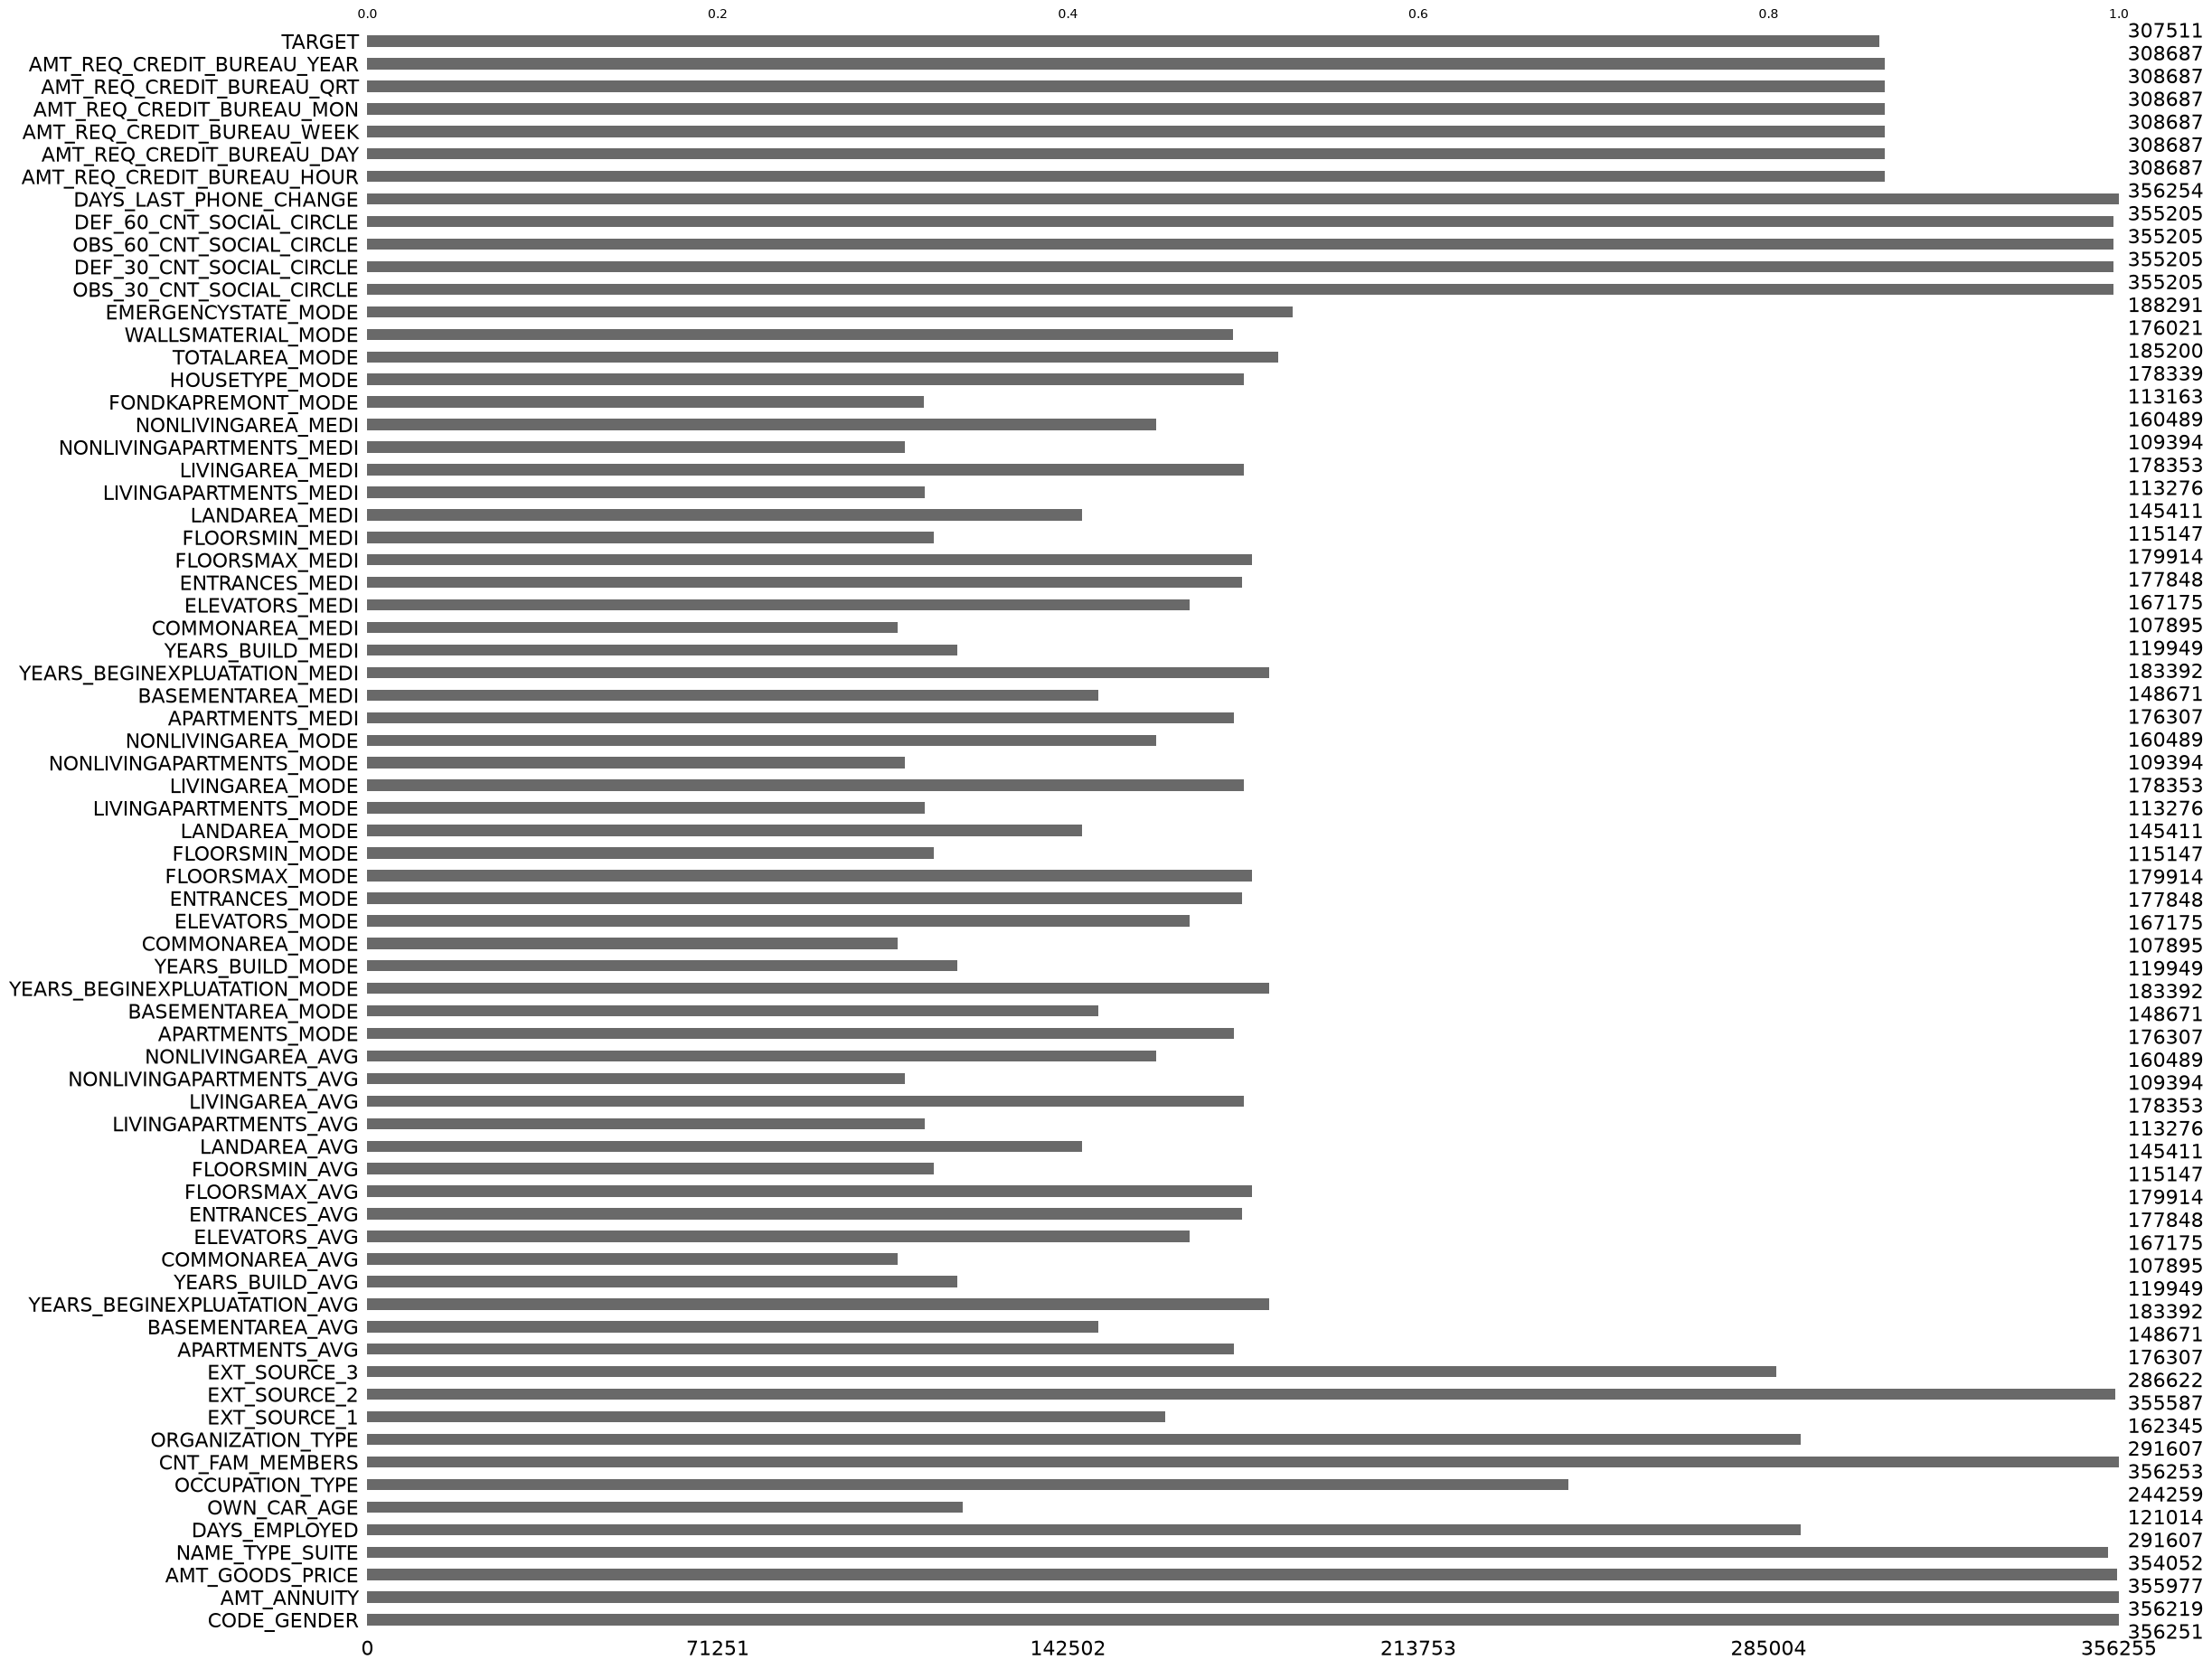

In [11]:
import missingno as msno
msno.bar(df.loc[:,df.isna().sum()>0])

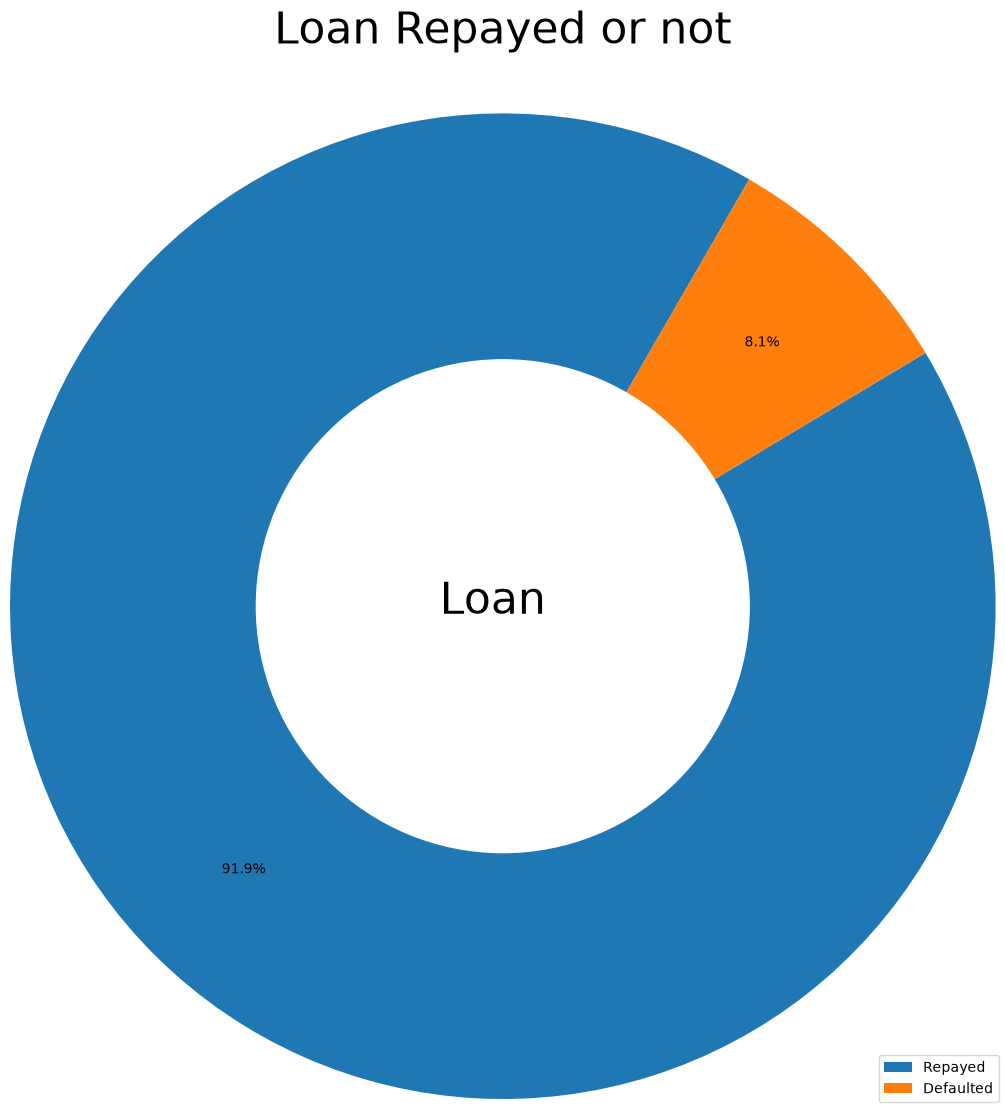

In [12]:
pie_chart(df)

## Continous features

We notice some obvious outliers, for example AMT_INCOME_TOTAL, one data point is equal to 117,000,000, this will be removed before doing our model.
DAYS_LAST_PHONE_CHANGE, we have a peak at 0, 0 should be missing values.

In [13]:
df = df_prepared.copy()

In [14]:
cols = ['CREDIT_INCOME_RATIO', 'AMT_CREDIT', 'AMT_INCOME_TOTAL'] + ['ANNUITY_INCOME_RATIO', 'AMT_ANNUITY'] + ['DAYS_EMPLOYED_RATIO', 'DAYS_EMPLOYED', 'DAYS_BIRTH']

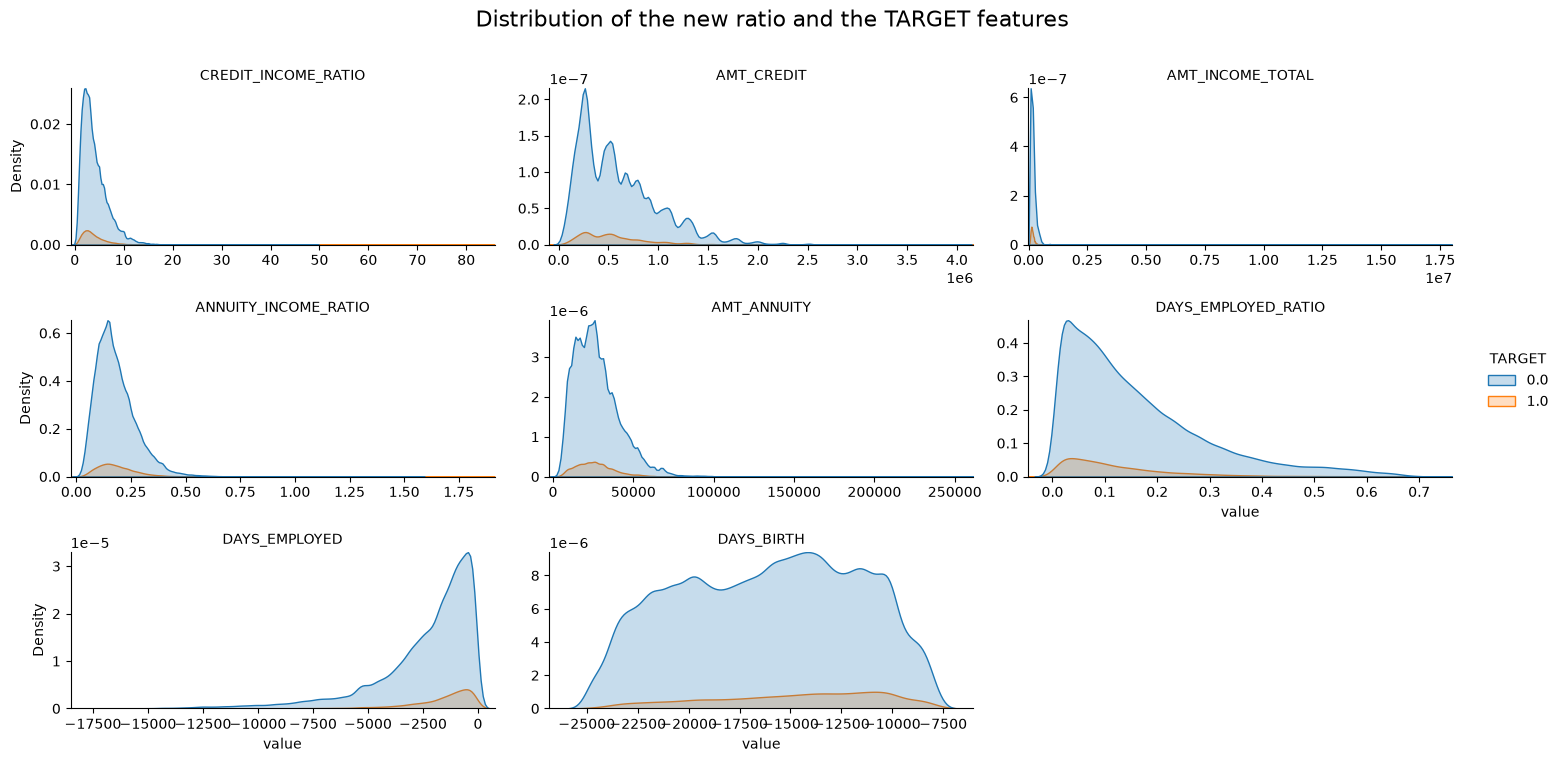

In [15]:
# convert the dataframe from wide to 
dfm = df[cols+['TARGET']].loc[:,df[cols+['TARGET']].std()>0].melt(id_vars='TARGET', var_name='Distribution')
# plot
g = sns.displot(kind='kde', data=dfm, col='Distribution', col_wrap=3, x='value', hue='TARGET', fill=True, palette='tab10', warn_singular=False, facet_kws={'sharey': False, 'sharex': False}, height=2.5, aspect=2)

for ax in g.axes:
    ax.margins(x=0)
    ax.margins(y=0)

g.set_titles("{col_name}")
g.fig.suptitle('Distribution of the new ratio and the TARGET features', fontsize=16, y=1.01)
g.tight_layout()

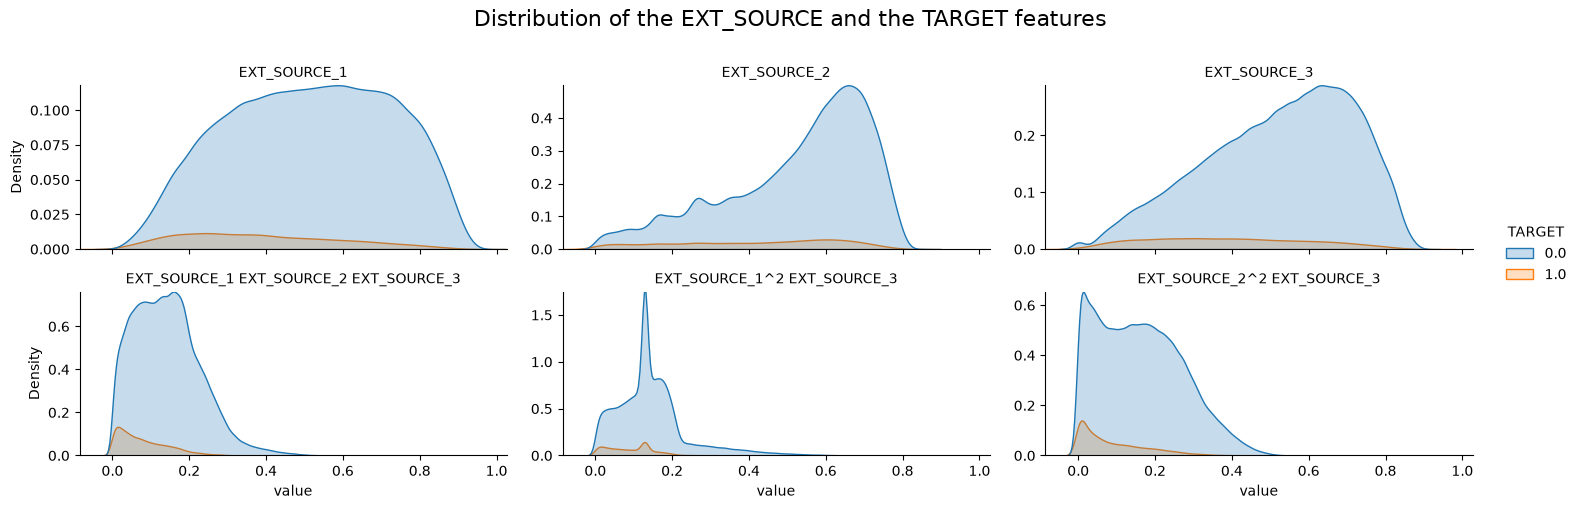

In [16]:
ext_source_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']+['EXT_SOURCE_1 EXT_SOURCE_2 EXT_SOURCE_3','EXT_SOURCE_1^2 EXT_SOURCE_3', 'EXT_SOURCE_2^2 EXT_SOURCE_3']
# convert the dataframe from wide to 
dfm = df[ext_source_cols+['TARGET']].loc[:,df[ext_source_cols+['TARGET']].std()>0].melt(id_vars='TARGET', var_name='Distribution')
# plot
g = sns.displot(kind='kde', data=dfm, col='Distribution', col_wrap=3, x='value', hue='TARGET', fill=True, palette='tab10', warn_singular=False, facet_kws={'sharey': False, 'sharex': True}, height=2.5, aspect=2)

for ax in g.axes:
    ax.margins(x=0)
    ax.margins(y=0)

g.set_titles("{col_name}")
g.fig.suptitle('Distribution of the EXT_SOURCE and the TARGET features', fontsize=16, y=1.01)
g.tight_layout()

DAYS_LAST_PHONE_CHANGE
-1.0       2986
-2.0       2389
-3.0       1808
-4.0       1328
-5.0        859
           ... 
-4009.0       1
-3576.0       1
-3475.0       1
-3780.0       1
-3777.0       1
Name: count, Length: 3845, dtype: int64

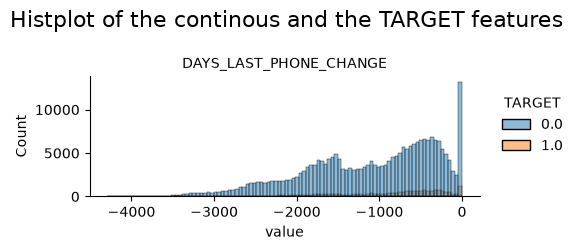

In [17]:
continous_cols = [col for col in df.select_dtypes(include='float64').columns if col not in index_cols] 

continous_cols = ['DAYS_LAST_PHONE_CHANGE']

# convert the dataframe from wide to 
dfm = df[continous_cols+['TARGET']].loc[:,df[continous_cols+['TARGET']].std()>0].melt(id_vars='TARGET', var_name='Distribution')
# plot
g = sns.displot(kind='hist', data=dfm, col='Distribution', col_wrap=1, x='value', hue='TARGET', fill=True, palette='tab10', bins=100,facet_kws={'sharey': False, 'sharex': False}, height=2.5, aspect=2)


    

g.set_titles("{col_name}")
g.fig.suptitle('Histplot of the continous and the TARGET features', fontsize=16) 

g.tight_layout()

df.DAYS_LAST_PHONE_CHANGE.value_counts()

## Discrete features

In [18]:
#df.columns.sort_values().tolist()

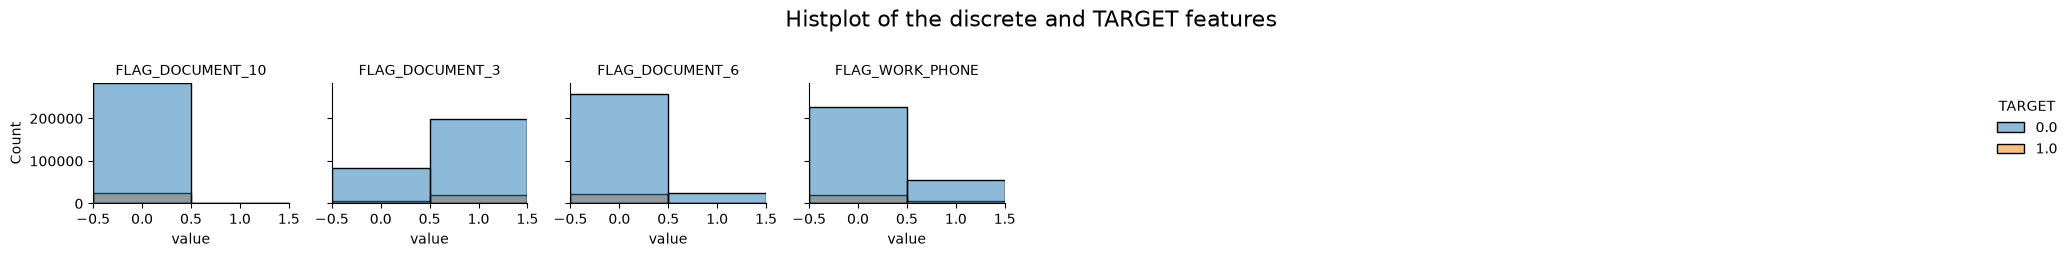

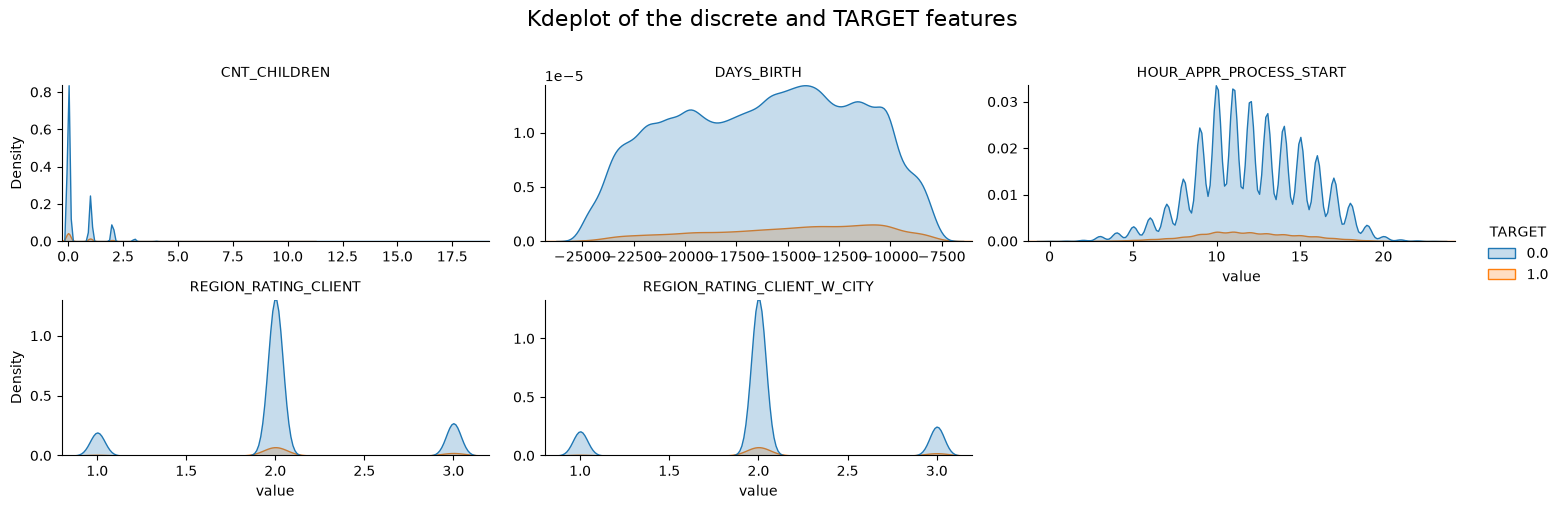

In [19]:
discrete_cols = [col for col in df.select_dtypes(include='int64').columns if col not in index_cols] 

discrete_hist_cols, discrete_kde_cols = [],[]
for col in df[discrete_cols].columns:
    if len(df[col].unique()) < 3:
        discrete_hist_cols.append(col)
    else:
        discrete_kde_cols.append(col)
        
discrete_hist_cols = ['FLAG_DOCUMENT_10', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_6', 'FLAG_WORK_PHONE'] 
        
display_discrete(df, discrete_hist_cols, 'TARGET', kind='hist')
display_discrete(df, discrete_kde_cols, 'TARGET', kind='kde')

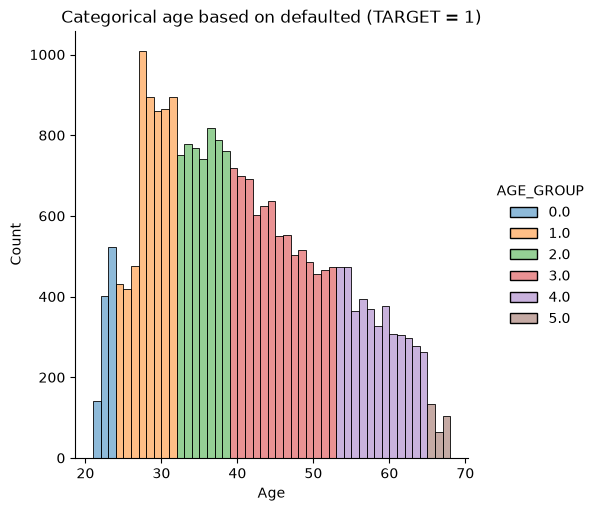

In [20]:
df = df_visualization.copy()

sns.displot(data=df[df.TARGET==1], x=np.floor(-df['DAYS_BIRTH'] / 365), hue='AGE_GROUP', palette="tab10", binwidth=1, kind="hist")

plt.xlabel('Age')
plt.title('Categorical age based on defaulted (TARGET = 1)')

plt.show()

## Category features

In [21]:
df = df_visualization.copy()

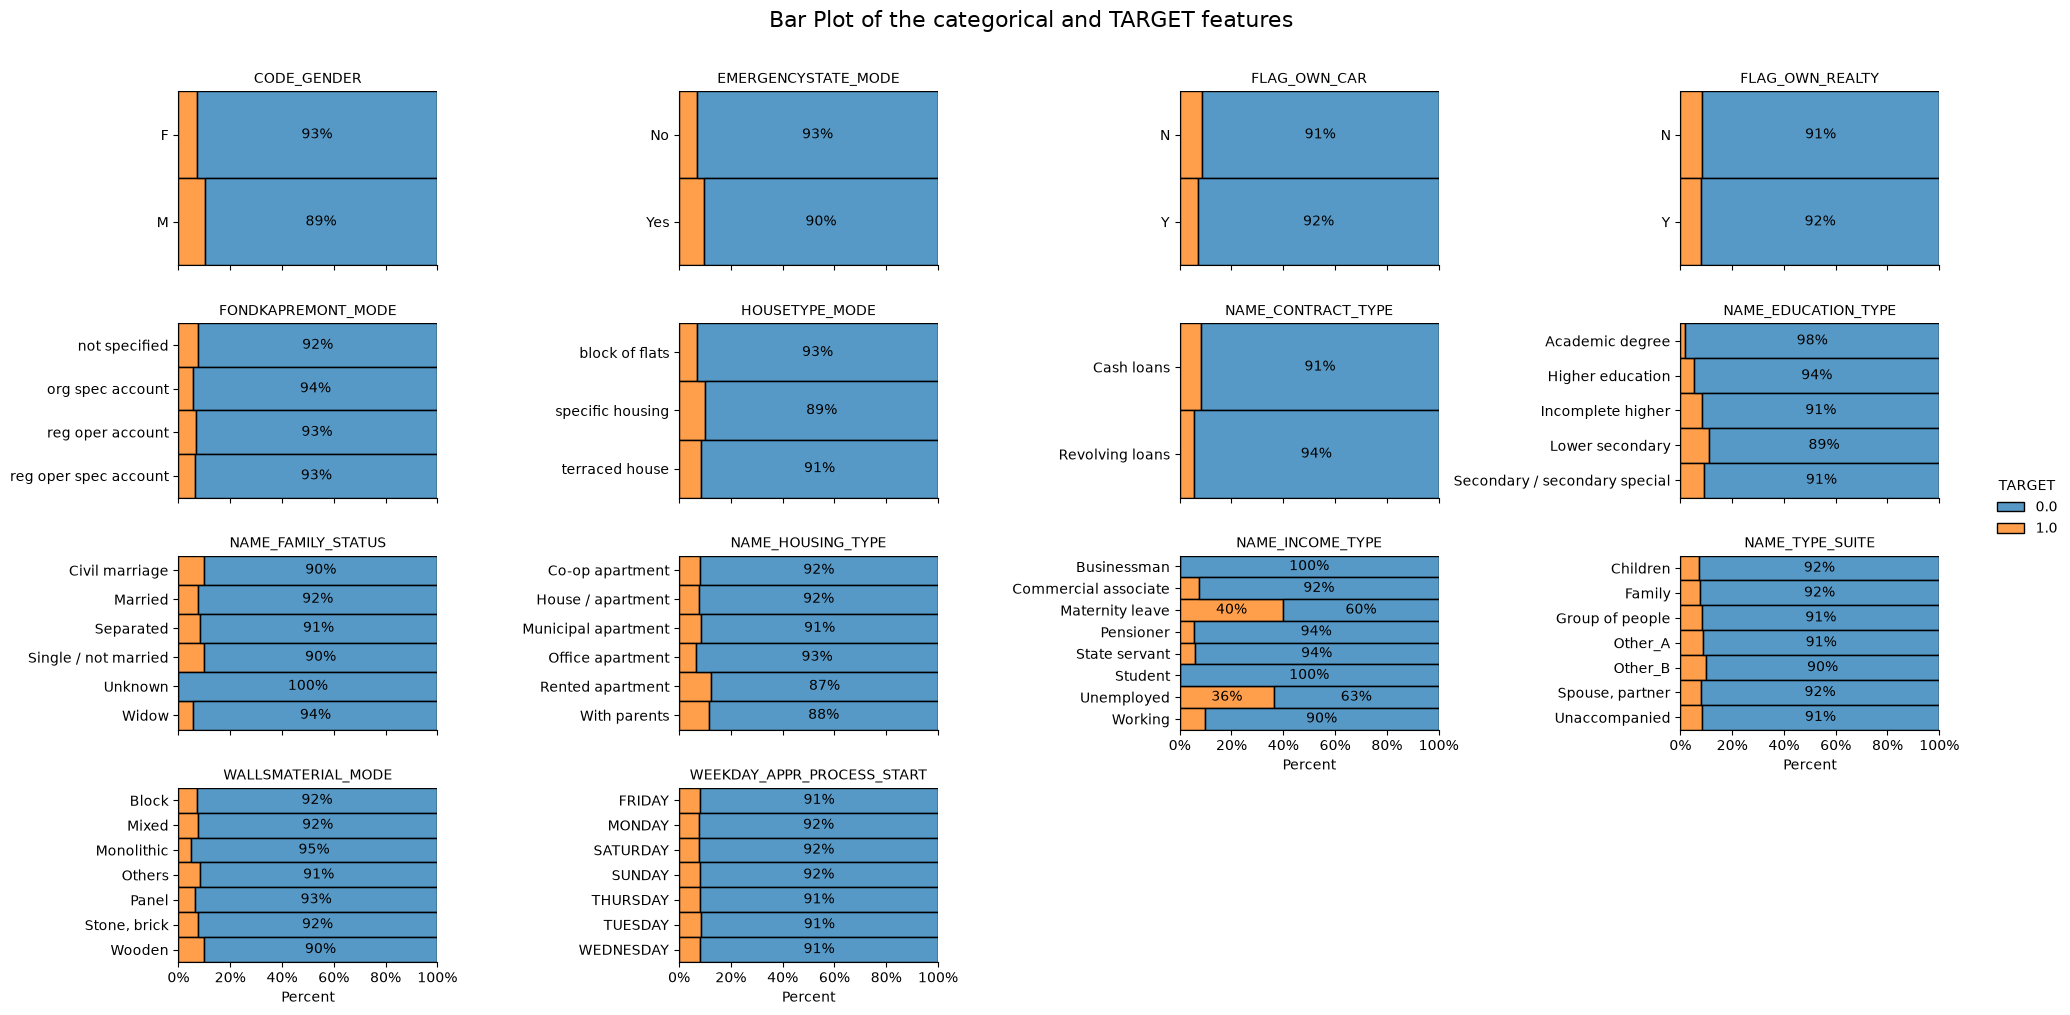

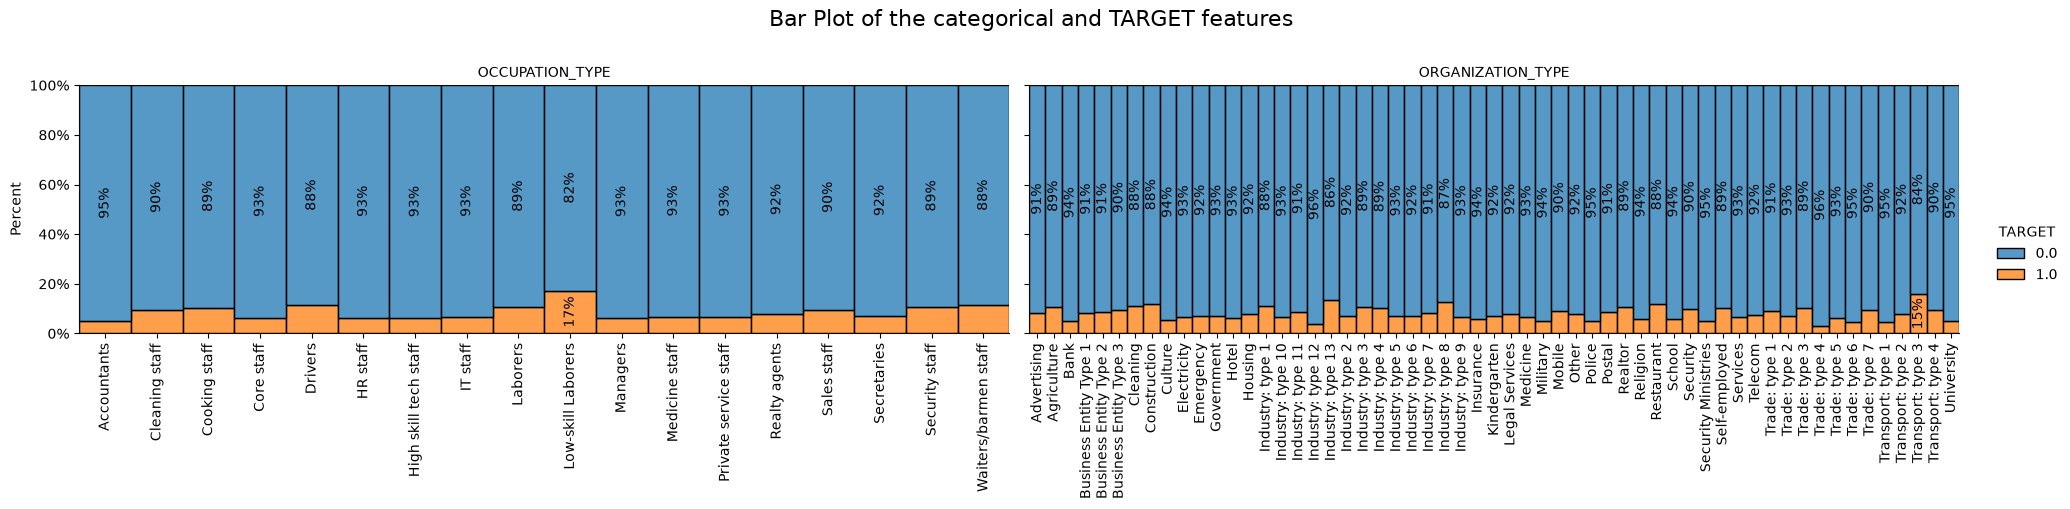

In [22]:
category_cols = [col for col in df.select_dtypes(include=["object", "string"]).columns if col not in index_cols]

# If the number of unique value is high, it will be displayed vertically
category_h_cols, category_v_cols = [],[]
for col in df[category_cols].columns:
    if len(df[col].unique()) < 10:
        category_h_cols.append(col)
    else:
        category_v_cols.append(col)

display_categorical(df, category_h_cols, 'TARGET', height=2.5, aspect=2)
display_categorical(df, category_v_cols, 'TARGET', height=5, aspect=2, orient='v')

We notice some binary category, eg: FLAG_OWN_CAR, will be replace by a binary column 0 or 1. We need to look deeper in some category, for example NAME_INCOME_TYPE, Unemployed and Maternity leave are risky.